# ResNet-50 Architecture (Detailed)

---

## 1. Plain Networks and the Problems with Deep Networks

Earlier deep neural networks were plain — i.e., layers were stacked sequentially without any shortcuts or additional paths. However, this approach suffered from:

- **Vanishing/Exploding Gradients**: As the number of layers increases, gradients can become extremely small or large during backpropagation, making training unstable.
- **Degradation Problem**: Increasing network depth does not guarantee better accuracy; in fact, it often leads to worse performance because deeper models become harder to optimize.

---

## 2. Introduction to Residual Learning

Instead of directly learning the mapping \( H(x) \), ResNet proposes to learn the residual function \( F(x) = H(x) - x \), so the final output becomes:

\[
H(x) = F(x) + x
\]

This concept assumes that it is easier to learn the residual (the change needed) rather than the full transformation.

---

## 3. Skip Connections (Shortcut Connections)

To implement residual learning, **skip connections** are used. These allow input to bypass intermediate layers and be added directly to the output.

- **Identity Skip Connection**: If input and output dimensions match, the input is added directly:  
  \( y = F(x) + x \)

- **Projection Skip Connection**: If dimensions differ, a linear transformation (usually 1×1 conv) is applied to the input before adding:  
  \( y = F(x) + W_s x \)

These connections enable better gradient flow, making it easier to train deep models.

---

## 4. ResNet Architecture

ResNet stands for **Residual Network**. It uses residual blocks as its core building units.

### Key Components of a Residual Block:
- Two or three convolutional layers
- Batch Normalization (BN) after each conv layer
- ReLU activation
- Skip (shortcut) connection

These blocks are repeated to build deeper networks.

---

## 5. ResNet Variants

| Variant     | Total Layers |
|-------------|--------------|
| ResNet-18   | 18           |
| ResNet-34   | 34           |
| ResNet-50   | 50 *(uses bottleneck blocks)* |
| ResNet-101  | 101          |
| ResNet-152  | 152          |

---

## 6. Identity Mapping in ResNet

When input and output dimensions are the same, skip connections perform identity mapping — passing the input directly to the output. This helps maintain information flow and supports deeper training.

---

## 7. How ResNet Works

- Learns spatial features using convolutional layers.
- Uses **Batch Normalization** to stabilize and speed up training.
- Applies **ReLU** to introduce non-linearity.
- Adds **Skip Connections** to bypass layers, preventing vanishing/exploding gradients.
- Trained using **Backpropagation**, but the skip connections make gradient flow efficient even in deep networks.

---

## 8. Advantages of ResNet

- ✅ **Solves Vanishing Gradient Problem**
- ✅ **Supports Very Deep Networks** (100+ layers)
- ✅ **Improves Generalization**
- ✅ **High Performance** on ImageNet, COCO, etc.

---

## 9. Disadvantages of ResNet

- ❌ **Computationally Expensive** (needs powerful GPUs)
- ❌ **Complex to Debug** due to depth
- ❌ **Risk of Overfitting** on small datasets

---

## 10. ResNet-50 on ImageNet

- Trained on ImageNet (1.2M+ images, 1000 classes)
- **Top-5 error rate**: ~5.25%
- **Deeper versions (101, 152)** perform even better, thanks to skip connections which make them trainable unlike plain deep networks.

---

## 11. Bottleneck Architecture in ResNet

Used in ResNet-50 and deeper variants:

- Uses a **1×1 conv → 3×3 conv → 1×1 conv** sequence.
- Reduces, processes, and then restores feature dimensions.
- Improves computational efficiency without compromising accuracy.

---

## 12. Additional Concepts

- **Batch Normalization**: Normalizes inputs to layers for faster convergence.
- **Convolution Types**:  
  - 1×1: Reduces/expands feature depth  
  - 3×3: Main spatial feature extraction  
- **ResNeXt**: An improved version of ResNet introducing *cardinality* (number of independent paths) to enhance performance.

---

## Summary Table: ResNet-50 Architecture

| Layer Block | Type                      | Output Size | Filters         | Kernel | Stride | Skip Connection |
|-------------|---------------------------|-------------|-----------------|--------|--------|-----------------|
| Conv1       | 7×7 Conv + MaxPool        | 112×112     | 64              | 7×7    | 2      | No              |
| Conv2_x     | 3 Bottleneck Blocks       | 56×56       | 64, 64, 256     | 1×1,3×3,1×1 | -  | Yes (identity) |
| Conv3_x     | 4 Bottleneck Blocks       | 28×28       | 128,128,512     | 1×1,3×3,1×1 | -  | Yes            |
| Conv4_x     | 6 Bottleneck Blocks       | 14×14       | 256,256,1024    | 1×1,3×3,1×1 | -  | Yes            |
| Conv5_x     | 3 Bottleneck Blocks       | 7×7         | 512,512,2048    | 1×1,3×3,1×1 | -  | Yes            |
| FC          | Fully Connected + Softmax | 1×1         | 1000 classes    | -      | -      | -               |

---

## Developed By & Timeline

- **Developed by**: Microsoft Research
- **Published**: 2015 (CVPR paper: *“Deep Residual Learning for Image Recognition”*)
- **Won**: ImageNet 2015 classification task

---

## Applications

- Image classification (ImageNet, CIFAR)
- Object detection (Faster R-CNN, Mask R-CNN)
- Medical imaging
- Face recognition
- Video recognition

---

## Influence and Follow-up Architectures

- **ResNeXt** – Introduced cardinality
- **DenseNet** – Extended connectivity ideas
- **EfficientNet**, **SENet**, **Transformer-based models** – Inspired by residual connections and scalability


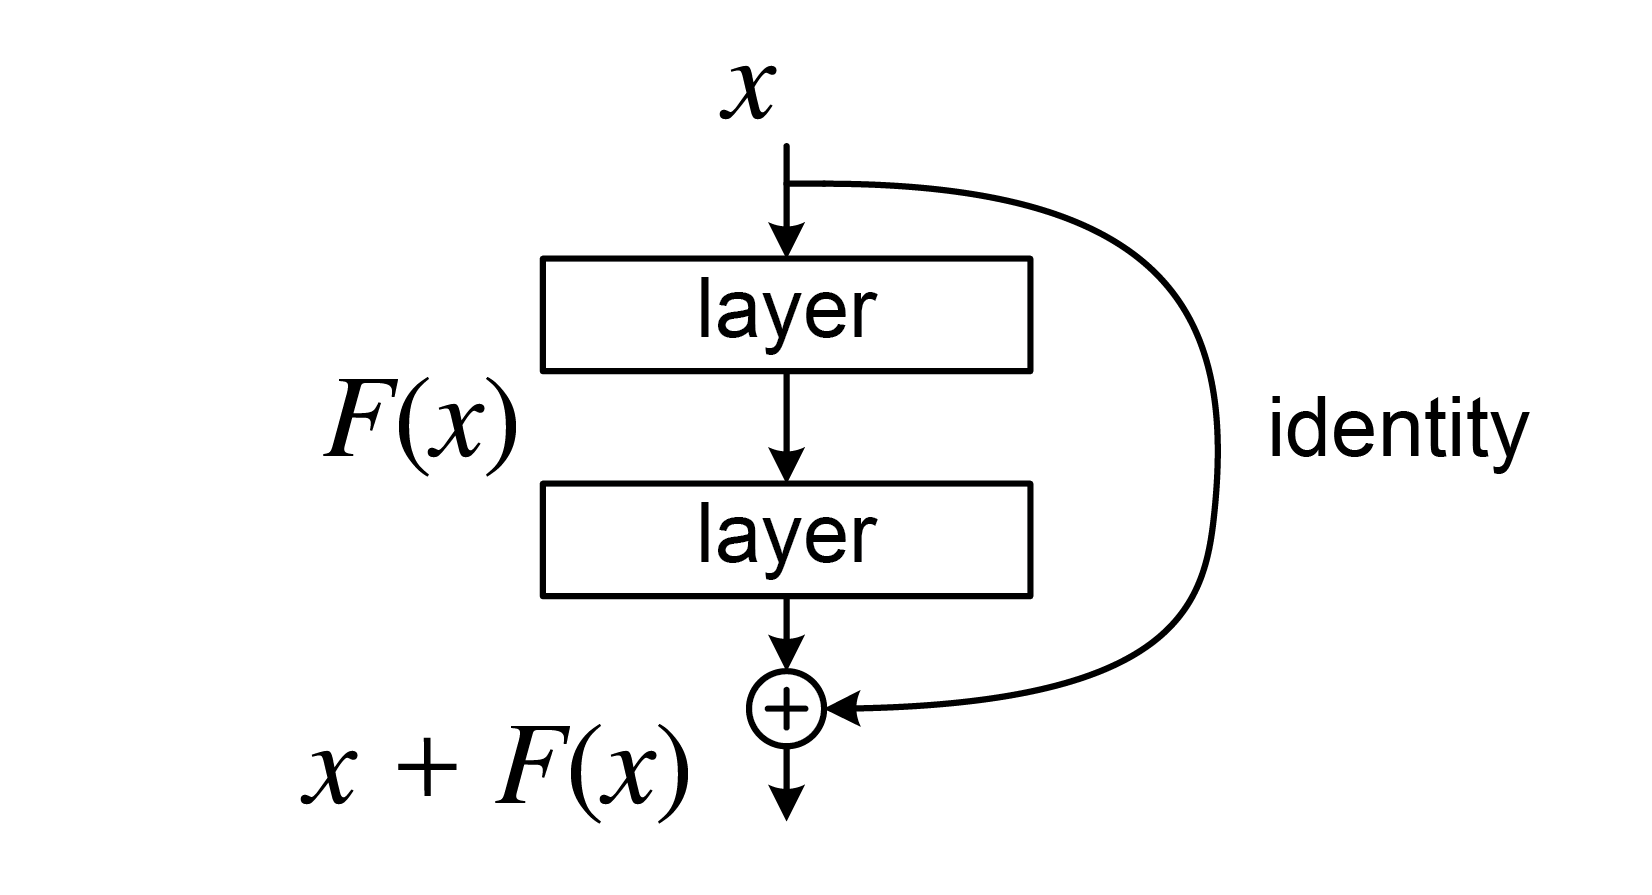

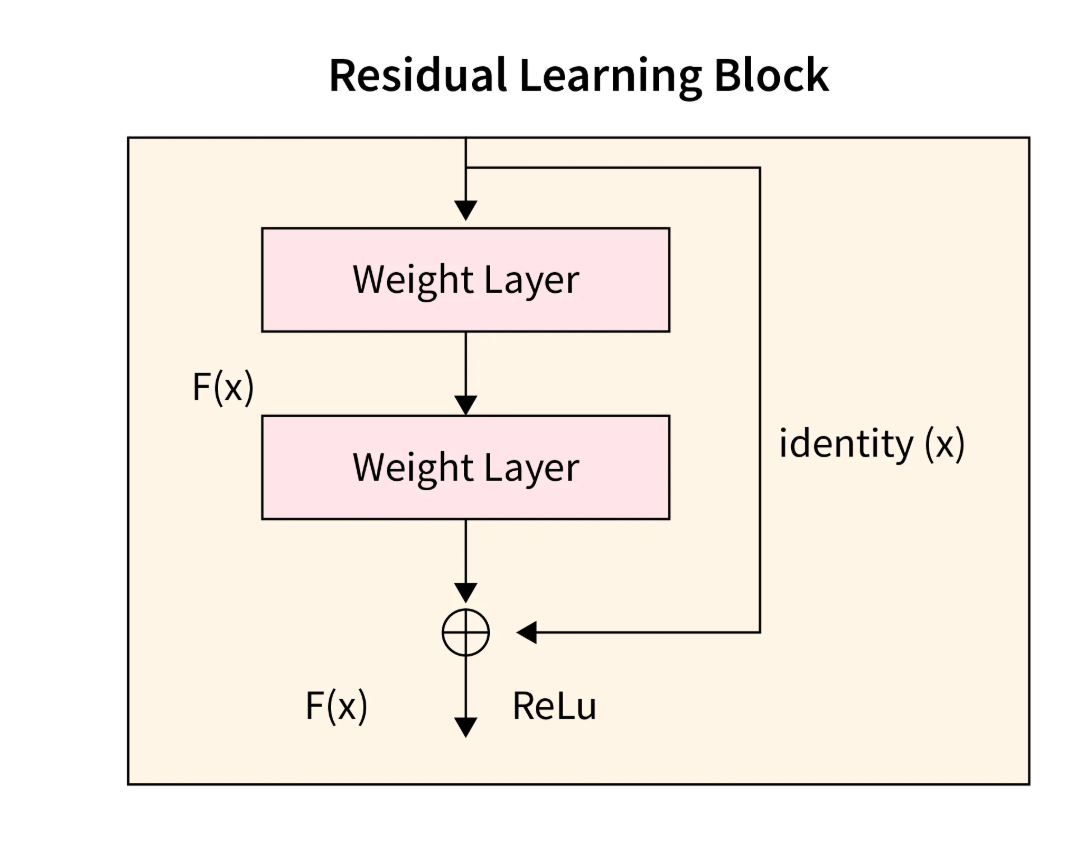

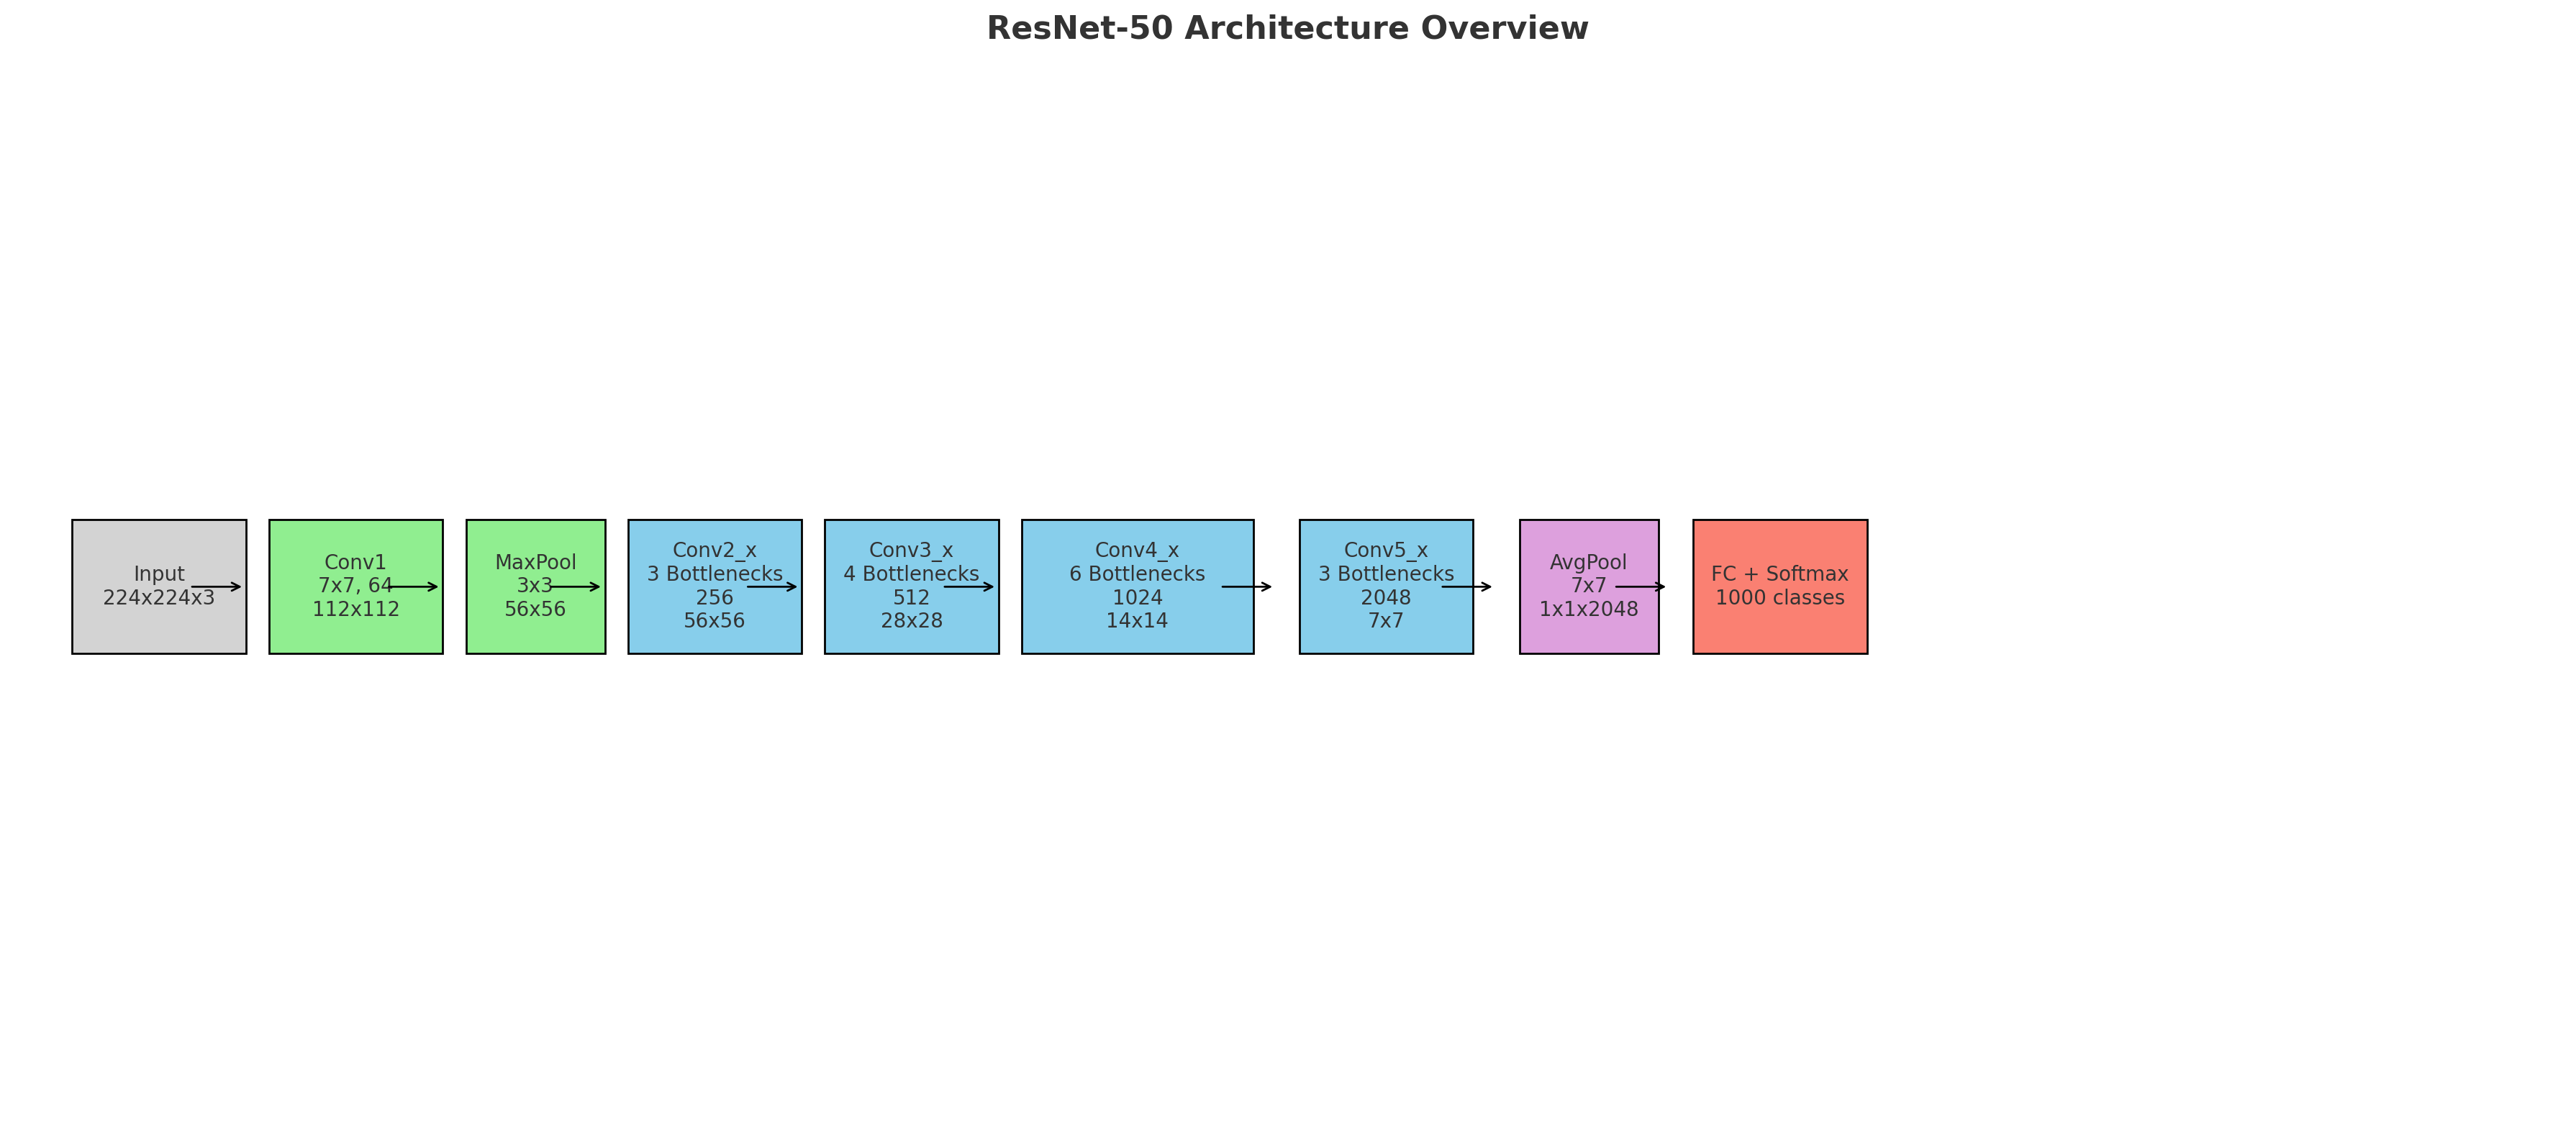

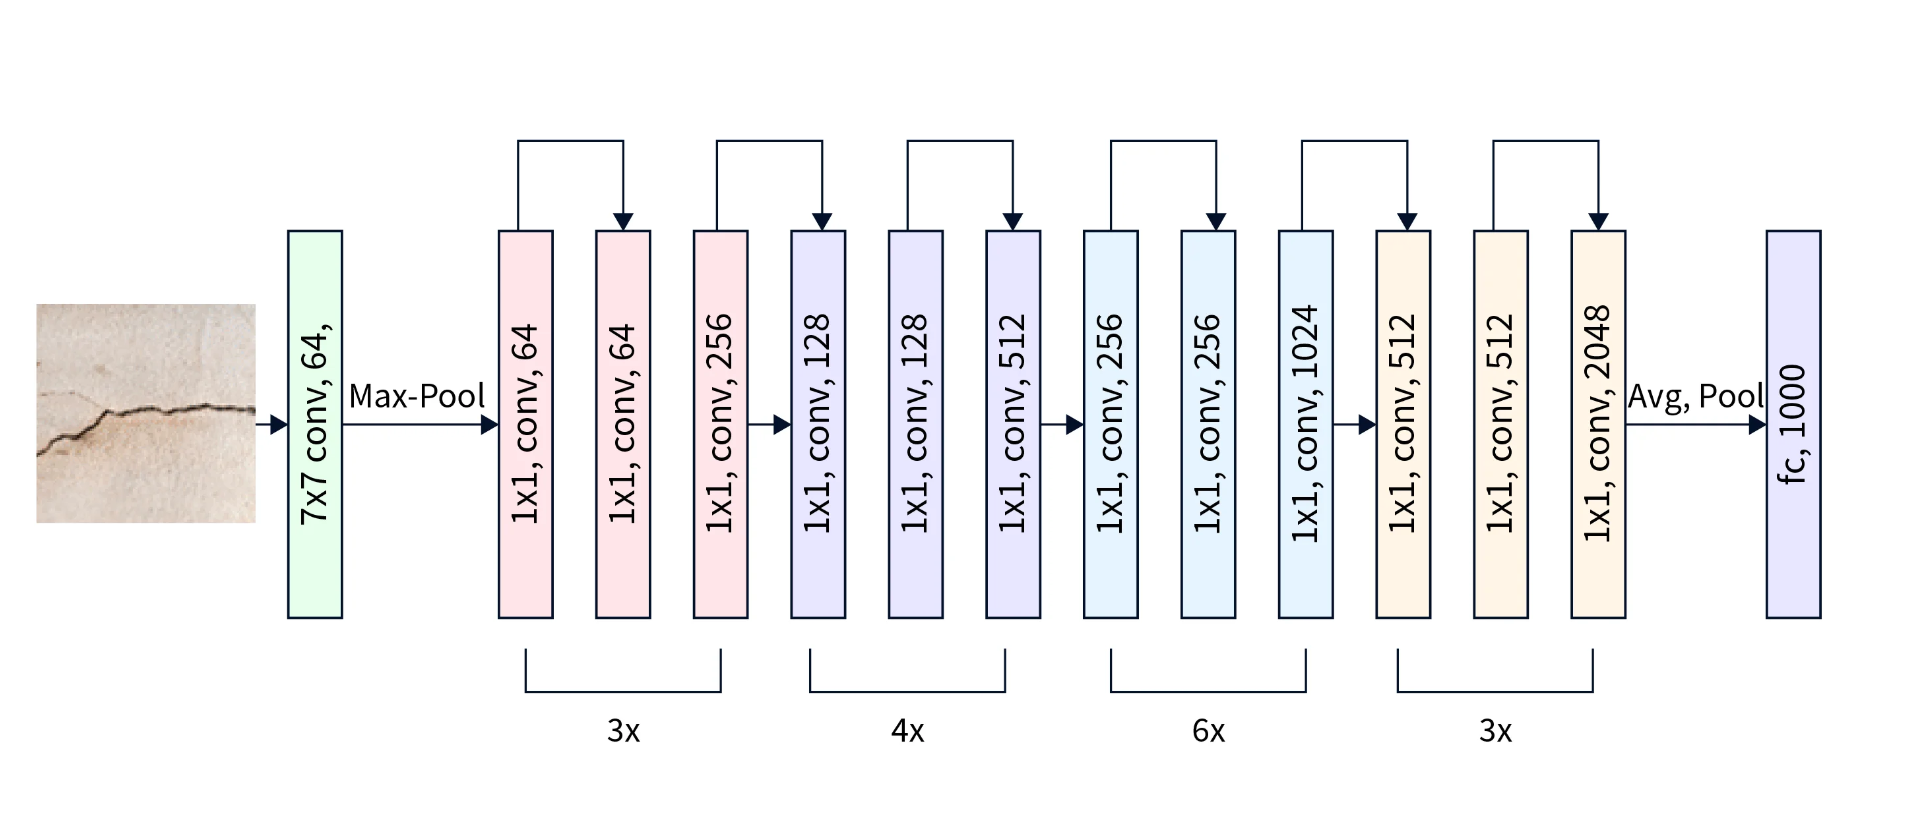

# 🧠 ResNet-50 Architecture (Detailed Block-by-Block)

## Input
- **Input Shape**: 224×224×3 (RGB Image)

---

## 1️⃣ Conv1 (Initial Convolution)
- **Layer**: 7×7 convolution with 64 filters, stride 2, padding 3 → Output: 112×112×64
- **Followed by**: Batch Normalization, ReLU, and MaxPooling (3×3, stride 2) → Output: 56×56×64

---

## 2️⃣ Conv2_x Block
- **Number of Bottleneck Blocks**: 3
- **Each Bottleneck Block**:
  - 1×1 conv (64 filters, reduce dims)
  - 3×3 conv (64 filters, spatial conv)
  - 1×1 conv (256 filters, restore dims)
- **Skip connections** added to each block
- **Output Feature Map**: 56×56×256

---

## 3️⃣ Conv3_x Block
- **Number of Bottleneck Blocks**: 4
- **Each Bottleneck Block**:
  - 1×1 conv (128 filters)
  - 3×3 conv (128 filters)
  - 1×1 conv (512 filters)
- **First block uses stride 2 to downsample**
- **Output Feature Map**: 28×28×512

---

## 4️⃣ Conv4_x Block
- **Number of Bottleneck Blocks**: 6
- **Each Bottleneck Block**:
  - 1×1 conv (256 filters)
  - 3×3 conv (256 filters)
  - 1×1 conv (1024 filters)
- **First block uses stride 2 to downsample**
- **Output Feature Map**: 14×14×1024

---

## 5️⃣ Conv5_x Block
- **Number of Bottleneck Blocks**: 3
- **Each Bottleneck Block**:
  - 1×1 conv (512 filters)
  - 3×3 conv (512 filters)
  - 1×1 conv (2048 filters)
- **First block uses stride 2 to downsample**
- **Output Feature Map**: 7×7×2048

---

## 🔚 Final Layers
- **Global Average Pooling**: Converts 7×7×2048 → 1×1×2048
- **Fully Connected (Dense)**: 2048 → 1000 (for ImageNet classes)
- **Activation**: Softmax

---

## 🔁 Total Parameters
- ~25.6 million parameters
- Depth: 50 layers (including all conv, FC, BN layers)

---

## ✅ Summary Table

| Block      | # Bottlenecks | Filters per block | Output Size     |
|------------|----------------|-------------------|------------------|
| Conv1      | 1              | 64 (7×7)           | 112×112×64       |
| Conv2_x    | 3              | 64, 64, 256        | 56×56×256        |
| Conv3_x    | 4              | 128, 128, 512      | 28×28×512        |
| Conv4_x    | 6              | 256, 256, 1024     | 14×14×1024       |
| Conv5_x    | 3              | 512, 512, 2048     | 7×7×2048         |
| FC Layer   | -              | -                  | 1000 classes     |

---


# InceptionNet (GoogLeNet to Inception-v4)

---

## 1. Problems with Traditional CNNs (Plain Networks)

Traditional CNNs such as VGGNet have several limitations:

- **Computational Cost:** Large filter sizes (e.g., 5×5) and deep stacks increase the computational load and memory usage.
- **Overfitting:** With many parameters, deep networks are prone to overfitting, especially with limited data.
- **Lack of Multi-Scale Feature Extraction:** Using fixed-size filters per layer limits the network’s ability to capture patterns at various spatial scales.
- **Degradation Problem:** Increasing network depth can degrade performance due to vanishing gradients and difficulty in optimization.

---

## 2. How InceptionNet Solves These Problems

### ✅ Inception Module

- Applies **1×1, 3×3, 5×5 convolutions**, and **3×3 max pooling** **in parallel** within a single layer.
- **Concatenates outputs along the depth axis**, allowing the model to extract features at multiple scales.

### ✅ Dimensionality Reduction

- **1×1 convolutions** are used before expensive convolutions (3×3, 5×5) to **reduce channel depth**, lowering computation and overfitting.

### ✅ Efficient Computation

- Replaces large filters (e.g., 5×5) with **multiple smaller filters** (e.g., two 3×3), reducing FLOPs while maintaining receptive field.

---

## 3. Why It’s Called “Inception”?

- The name is inspired by the movie *Inception* with the phrase “We need to go deeper,” referring to deep, nested architectures and multi-level feature learning.

---

## 4. Evolution of Inception Versions

### 🔹 Inception v1 (GoogLeNet)

- **22 layers deep**, composed of **9 inception modules**
- Includes **two auxiliary classifiers** (branch classifiers during training to help gradient flow)
- Ends with **Global Average Pooling** instead of fully connected layers

**Architecture Highlights:**
- Conv → MaxPool → Conv → MaxPool → Inception Modules ×9 → AvgPool → FC → Softmax
- Uses 1×1 Convs for dimensionality reduction
- ~5 million parameters (far fewer than VGG-16)

---

### 🔹 Inception v2

- **Factorizes** large convolutions:  
  e.g., 5×5 → two 3×3, and 3×3 → asymmetric filters like 3×1 + 1×3
- Adds **Batch Normalization** to all layers

---

### 🔹 Inception v3

- Further improves with:
  - **RMSProp** optimizer
  - **Label smoothing**
  - Better regularization
  - **Efficient grid size reduction** modules
- Uses deeper factorized convolutions for better efficiency

---

### 🔹 Inception v4

- Combines **Inception modules with Residual Connections**
- Uses **Inception-ResNet blocks**
- Allows training of deeper architectures with better gradient flow

---

## 5. InceptionNet Architecture (Block-Level Breakdown for v1)

| Block               | Operation                                                                 |
|---------------------|---------------------------------------------------------------------------|
| Input               | 224×224×3 RGB image                                                       |
| Conv1               | 7×7 Conv, 64 filters, stride 2 → Output: 112×112×64                        |
| MaxPool1            | 3×3 Max Pool, stride 2 → Output: 56×56×64                                  |
| Conv2               | 1×1 Conv (64) → 3×3 Conv (192) → Output: 56×56×192                         |
| MaxPool2            | 3×3 Max Pool, stride 2 → Output: 28×28×192                                 |
| Inception (3a, 3b)  | Multiple filters: 1×1, 3×3, 5×5, 3×3 MaxPool                               |
| MaxPool3            | 3×3 Max Pool, stride 2                                                    |
| Inception (4a–4e)   | Deeper inception modules                                                  |
| Auxiliary Classifier 1 | Output from Inception 4a → Conv + FC + Softmax (used during training)  |
| Inception (5a–5b)   | Final inception modules                                                   |
| AvgPool             | Global Average Pooling (7×7)                                              |
| Dropout             | 40% dropout rate                                                          |
| FC (Softmax)        | Fully connected → 1000-class classification (e.g., ImageNet)              |

---

## 6. Summary of Improvements Across Versions

| Version     | Key Innovations                                               |
|-------------|---------------------------------------------------------------|
| Inception v1| Multi-scale Inception module + 1×1 conv + Global Avg Pool    |
| Inception v2| Factorization of convolutions + BatchNorm                     |
| Inception v3| RMSProp + Label smoothing + deeper modules                    |
| Inception v4| Residual connections + deeper Inception-ResNet blocks         |

---

## 7. Advantages and Disadvantages

### ✅ Advantages

- **Multi-scale feature learning** via parallel filters
- **Parameter-efficient** compared to VGG/ResNet
- **Good accuracy** on benchmark datasets
- **Dimensionality reduction** helps reduce overfitting and cost

### ❌ Disadvantages

- **Complex architecture** with many branches
- **Challenging to implement and debug**
- **High memory usage** during training

---

## 8. Applications

- **Image Classification** (e.g., ImageNet)
- **Object Detection** (e.g., SSD, Faster R-CNN backbones)
- **Transfer Learning** (widely used pre-trained models)



# Inception-v1 Architecture (GoogLeNet) — Layer-by-Layer Breakdown

---

## 📘 Introduction

- Developed by Google (2014), Inception-v1 (also called GoogLeNet) introduced the *Inception Module*, enabling efficient multi-scale feature extraction.
- Designed to reduce parameters while increasing network depth.
- Achieved **2nd place in ILSVRC-2014** classification and **1st place in detection**.

---

## 📐 Architecture Overview

### Input: 224×224×3 RGB Image

| Layer                   | Feature Map      | Kernel Size        | Stride | Padding | Activation |
|-------------------------|------------------|---------------------|--------|---------|------------|
| Conv1                   | 112×112×64       | 7×7                 | 2      | 3       | ReLU       |
| MaxPool1                | 56×56×64         | 3×3                 | 2      | 1       | -          |
| Conv2a                  | 56×56×64         | 1×1                 | 1      | 0       | ReLU       |
| Conv2b                  | 56×56×192        | 3×3                 | 1      | 1       | ReLU       |
| MaxPool2                | 28×28×192        | 3×3                 | 2      | 1       | -          |

---

## 🔲 Inception Modules

Each module applies 1×1, 3×3, 5×5 convolutions and 3×3 max pooling in parallel, followed by concatenation across depth.

### Inception 3a → Output: 28×28×256

| Path                | Layers                           | Output Depth |
|---------------------|-----------------------------------|--------------|
| 1×1 Conv            | 1×1 Conv                          | 64           |
| 3×3 Conv            | 1×1 Conv → 3×3 Conv               | 128          |
| 5×5 Conv            | 1×1 Conv → 5×5 Conv               | 32           |
| Pooling             | 3×3 MaxPool → 1×1 Conv            | 32           |
| **Concat Total**    |                                   | **256**      |

---

### Inception 3b → Output: 28×28×480

| Path                | Layers                           | Output Depth |
|---------------------|-----------------------------------|--------------|
| 1×1 Conv            | 1×1 Conv                          | 128          |
| 3×3 Conv            | 1×1 Conv → 3×3 Conv               | 192          |
| 5×5 Conv            | 1×1 Conv → 5×5 Conv               | 96           |
| Pooling             | 3×3 MaxPool → 1×1 Conv            | 64           |
| **Concat Total**    |                                   | **480**      |

### MaxPool → 14×14×480

---

### Inception 4a → Output: 14×14×512  
👉 *Auxiliary Classifier 1 connects here*

### Inception 4b → Output: 14×14×512  
### Inception 4c → Output: 14×14×512  
### Inception 4d → Output: 14×14×528  
👉 *Auxiliary Classifier 2 connects here*

### Inception 4e → Output: 14×14×832  
→ MaxPool → 7×7×832

---

### Inception 5a → Output: 7×7×832  
### Inception 5b → Output: 7×7×1024  

---

## 🔚 Final Layers

| Layer              | Output Shape     | Notes                                 |
|--------------------|------------------|----------------------------------------|
| Global Avg Pool    | 1×1×1024         | AvgPool over 7×7 spatial dimensions     |
| Dropout            | -                | 40% dropout                            |
| Fully Connected    | 1000             | One neuron per class (ImageNet)        |
| Softmax            | 1000             | Final classification probabilities     |

---

## ⚙️ Auxiliary Classifiers (during training only)

- Connected at Inception 4a and 4d
- Each has:
  - 5×5 AvgPool → 1×1 Conv → FC → Softmax
- Help improve gradient flow and combat vanishing gradients.

---

## 🧮 Parameter Count

- Approx. **5 million** parameters — much fewer than VGG-16 (138M)

---

## ✅ Summary Table

| Layer Type      | Output Size     | Details                            |
|------------------|------------------|-------------------------------------|
| Conv + MaxPool   | 56×56×64         | 7×7 Conv → 3×3 Pool                |
| Conv + MaxPool   | 28×28×192        | 1×1 → 3×3 → 3×3 Pool               |
| Inception x2     | 28×28×480        | 3a, 3b                             |
| MaxPool          | 14×14×480        | 3×3 Pool                           |
| Inception x5     | 14×14×528–832    | 4a–4e                              |
| MaxPool          | 7×7×832          | 3×3 Pool                           |
| Inception x2     | 7×7×1024         | 5a, 5b                             |
| AvgPool + FC     | 1×1×1000         | GlobalAvg → Dropout → Dense       |

---



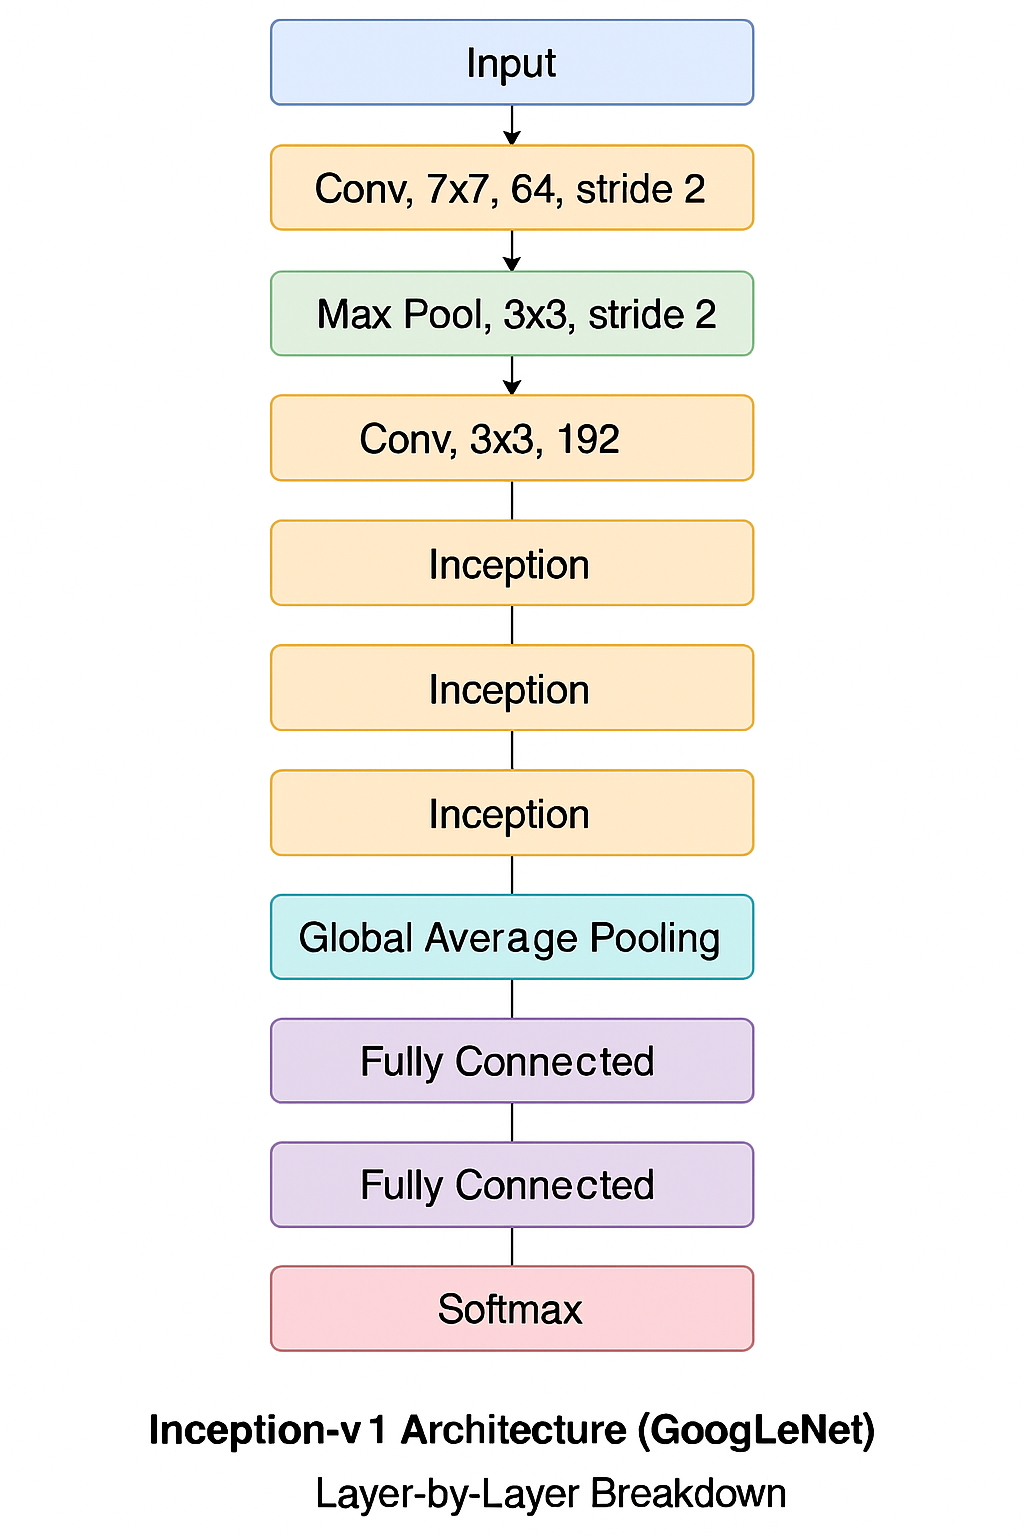

# Inception-v2 Architecture — Layer-by-Layer Breakdown

---

## 📘 Introduction

- Inception-v2 was proposed as an improvement over Inception-v1 (GoogLeNet) by optimizing computational efficiency and enhancing feature extraction.
- It introduces **factorization** of large convolutions and **Batch Normalization (BN)** for faster convergence.
- Key idea: Replace expensive 5×5 convolutions with two stacked 3×3 convolutions to reduce computation while preserving receptive field.

---

## 📐 Architecture Overview

### Input: 224×224×3 RGB Image

| Layer                   | Output Shape     | Kernel Size        | Stride | Padding | Notes                |
|-------------------------|------------------|---------------------|--------|---------|----------------------|
| Conv1                   | 112×112×64       | 7×7                 | 2      | 3       | ReLU + BN            |
| MaxPool1                | 56×56×64         | 3×3                 | 2      | 1       |                      |
| Conv2a                  | 56×56×64         | 1×1                 | 1      | 0       | ReLU + BN            |
| Conv2b                  | 56×56×192        | 3×3                 | 1      | 1       | ReLU + BN            |
| MaxPool2                | 28×28×192        | 3×3                 | 2      | 1       |                      |

---

## 🔲 Inception Modules (Factorized)

Each Inception module performs parallel convolutions using:

- 1×1 Convolution  
- 1×1 → 3×3 Convolution  
- 1×1 → 3×3 → 3×3 Convolution (*Factorized 5×5*)  
- 3×3 MaxPool → 1×1 Convolution  

All outputs are concatenated across the depth axis.

---

### Inception Blocks (3a to 5b)

| Block          | Output Size     | Notes                                                                 |
|----------------|------------------|-----------------------------------------------------------------------|
| Inception (3a) | 28×28×256        | First inception module with factorized 5×5 (→ two 3×3)               |
| Inception (3b) | 28×28×320        | Increased number of filters                                           |
| MaxPool        | 14×14×320        | Downsampling                                                          |
| Inception (4a) | 14×14×576        | Higher depth with more factorized paths                              |
| Inception (4b) | 14×14×576        | Similar structure, deeper filters                                     |
| Inception (4c) | 14×14×608        | Adds more capacity                                                   |
| Inception (4d) | 14×14×608        | Auxiliary classifier connects here (during training)                 |
| Inception (4e) | 14×14×832        | Final block before downsampling                                      |
| MaxPool        | 7×7×832          | Reduces spatial resolution                                            |
| Inception (5a) | 7×7×832          | Deep inception filters                                                |
| Inception (5b) | 7×7×1024         | Final Inception block                                                 |

---

## 🔚 Final Layers

| Layer              | Output Shape     | Notes                                    |
|--------------------|------------------|-------------------------------------------|
| Global Avg Pool    | 1×1×1024         | Average over 7×7 spatial dimensions       |
| Dropout            | -                | Typically 40% dropout                     |
| Fully Connected    | 1000             | For ImageNet classification               |
| Softmax            | 1000             | Final probabilities                       |

---

## ⚙️ Auxiliary Classifier (Only During Training)

Connected at Inception (4d) to help combat vanishing gradients.

- 5×5 AvgPool → 1×1 Conv → FC → Softmax
- Helps improve training convergence.

---

## 🔧 Key Innovations in Inception-v2

| Technique                        | Purpose                                      |
|----------------------------------|----------------------------------------------|
| **Factorized Convolutions**      | Reduce computation (5×5 → two 3×3)           |
| **Batch Normalization (BN)**     | Speed up training and stabilize gradients    |
| **Efficient Module Design**      | Retain multi-scale features with fewer FLOPs|

---

## ✅ Summary Table

| Layer Type        | Output Size     | Comments                                     |
|--------------------|------------------|----------------------------------------------|
| Conv + MaxPool     | 56×56×64         | Initial processing                           |
| Conv + MaxPool     | 28×28×192        | Prepares input for inception modules         |
| Inception x2       | 28×28×320        | Inception (3a, 3b)                            |
| MaxPool            | 14×14×320        | Downsampling                                 |
| Inception x4       | 14×14×576–832    | Inception (4a–4e)                             |
| MaxPool            | 7×7×832          | Downsampling                                 |
| Inception x2       | 7×7×1024         | Inception (5a, 5b)                            |
| AvgPool + FC       | 1×1×1000         | Final classification                         |

---



# Inception-v3 Architecture — Layer-by-Layer Breakdown

---

## 📘 Introduction

- Inception-v3 is an evolution of the Inception architecture focused on **improving accuracy and efficiency**.
- Introduced techniques like **factorized convolutions**, **label smoothing**, **RMSProp optimizer**, and **auxiliary classifiers**.
- Achieved **top-5 error of 3.5%** on ImageNet, surpassing previous versions.
- Developed by Google researchers in 2015.

---

## 📐 Architecture Overview

### Input: 299×299×3 RGB Image

| Layer               | Output Shape   | Kernel       | Stride | Padding | Activation |
|---------------------|----------------|--------------|--------|---------|------------|
| Conv1               | 149×149×32     | 3×3          | 2      | Valid   | ReLU       |
| Conv2               | 147×147×32     | 3×3          | 1      | Valid   | ReLU       |
| Conv3               | 147×147×64     | 3×3          | 1      | Same    | ReLU       |
| MaxPool1            | 73×73×64       | 3×3          | 2      | Valid   | -          |
| Conv4               | 73×73×80       | 1×1          | 1      | Valid   | ReLU       |
| Conv5               | 71×71×192      | 3×3          | 1      | Valid   | ReLU       |
| MaxPool2            | 35×35×192      | 3×3          | 2      | Valid   | -          |

---

## 🔲 Inception Modules

Inception-v3 uses three types of factorized inception blocks:
1. **Inception-A (35×35 grid)**
2. **Inception-B (17×17 grid)**
3. **Inception-C (8×8 grid)**

---

### 🔹 3× Inception-A Modules → Output: 35×35×288

Each module uses:
- 1×1 conv
- 1×1 → 3×3 conv
- 1×1 → 3×3 → 3×3 conv
- AvgPool → 1×1 conv  
All paths are concatenated.

---

### 🔻 Reduction-A → Output: 17×17×768

| Path         | Layers                      |
|--------------|------------------------------|
| Conv         | 3×3 stride 2 conv            |
| Conv-stack   | 1×1 → 3×3 → 3×3 (stride 2)   |
| Pool         | 3×3 MaxPool (stride 2)       |

---

### 🔹 4× Inception-B Modules → Output: 17×17×768

Each block uses:
- 1×1 conv
- 1×1 → 1×7 → 7×1 conv (factorized 7×7)
- 1×1 → 7×1 → 1×7 → 7×1 → 1×7 conv stack
- AvgPool → 1×1 conv  
→ Concatenated

---

### 🔻 Reduction-B → Output: 8×8×1280

| Path         | Layers                            |
|--------------|------------------------------------|
| Conv         | 1×1 → 3×3 → 3×3 stride 2           |
| Conv         | 1×1 → 3×3 stride 2                 |
| Pool         | 3×3 MaxPool stride 2               |

---

### 🔹 2× Inception-C Modules → Output: 8×8×2048

Each module uses:
- 1×1 conv
- 1×1 → parallel 1×3 and 3×1 conv
- 1×1 → 3×1 → 1×3 branch
- AvgPool → 1×1 conv  
→ Concatenated

---

## 🔚 Final Layers

| Layer              | Output Shape | Notes                          |
|--------------------|--------------|---------------------------------|
| Global Avg Pool    | 1×1×2048     | Pool over 8×8 grid             |
| Dropout            | -            | 40% dropout                    |
| Fully Connected    | 1000         | Dense layer                    |
| Softmax            | 1000         | Classification probabilities   |

---

## ⚙️ Auxiliary Classifier (Used During Training)

- Connected at 17×17×768 (after Inception-B)
- Layers:  
  → AvgPool (5×5) stride 3  
  → 1×1 Conv  
  → FC → Dropout → FC → Softmax  
- Helps combat vanishing gradients

---

## 📊 Summary Table

| Block Type         | Output Shape   | Notes                                 |
|---------------------|----------------|----------------------------------------|
| Conv + MaxPool      | 35×35×192      | Initial feature extraction             |
| Inception-A ×3      | 35×35×288      | Multi-path convs                       |
| Reduction-A         | 17×17×768      | Spatial downsampling                   |
| Inception-B ×4      | 17×17×768      | Factorized convolutions (7×7)          |
| Reduction-B         | 8×8×1280       | Further spatial downsampling           |
| Inception-C ×2      | 8×8×2048       | High-dimensional representations       |
| GlobalAvgPool + FC  | 1×1×1000       | Final classification                   |

---

## 📈 Parameter Count

- Around **23 million parameters**
- Lower than VGGNet (138M), but deeper and more optimized

---



# Inception-v4 Architecture — Layer-by-Layer Breakdown

---

## 📘 Introduction

- Inception-v4 combines **Inception modules** with **ResNet-style residual connections** (optional in Inception-ResNet variants).
- Released in 2016 by Google, it further improves classification performance and training speed.
- Unlike Inception-v3, it has a **pure and consistent modular design** with clearer separation between blocks.
- Input size: **299×299×3 RGB Image**

---

## 📐 Architecture Overview

| Stage              | Output Shape   | Description                            |
|--------------------|----------------|----------------------------------------|
| Stem               | 35×35×384      | Initial conv and pooling layers        |
| Inception-A ×4     | 35×35×384      | 4 modules with multi-scale filters     |
| Reduction-A        | 17×17×1024     | Downsampling block                     |
| Inception-B ×7     | 17×17×1024     | 7 modules with factorized convolutions |
| Reduction-B        | 8×8×1536       | Further downsampling                   |
| Inception-C ×3     | 8×8×1536       | High-level feature extraction          |
| Global Avg Pool    | 1×1×1536       | Reduces spatial dims                   |
| Dropout + Dense    | 1000           | Final classification layer             |

---

## 🔹 Stem Block (Input → 35×35×384)

| Layer                 | Output Shape   | Details                                  |
|------------------------|----------------|-------------------------------------------|
| Conv 3×3, stride 2     | 149×149×32     | No padding (VALID)                        |
| Conv 3×3               | 147×147×32     | VALID                                     |
| Conv 3×3               | 147×147×64     | SAME                                      |
| MaxPool 3×3, stride 2  | 73×73×64       | VALID                                     |
| Conv 1×1               | 73×73×80       | SAME                                      |
| Conv 3×3               | 71×71×192      | VALID                                     |
| MaxPool 3×3, stride 2  | 35×35×192      | VALID                                     |
| Conv + Split Paths     | 35×35×384      | Two branches with mixed conv operations   |

---

## 🔲 Inception-A Module ×4 → Output: 35×35×384

| Path         | Layers                                          | Output |
|--------------|--------------------------------------------------|--------|
| 1×1 Conv     | Single 1×1 conv                                 | 96     |
| 5×5 Conv     | 1×1 → 5×5                                        | 96     |
| 3×3 Stack    | 1×1 → 3×3 → 3×3                                  | 96     |
| Pool         | AvgPool → 1×1 conv                               | 96     |
| **Concat**   |                                                  | 384    |

---

## 🔻 Reduction-A → Output: 17×17×1024

| Path          | Layers                                           |
|---------------|--------------------------------------------------|
| Conv          | 3×3 stride 2                                     |
| Stack         | 1×1 → 3×3 → 3×3 stride 2                          |
| Pooling       | MaxPool 3×3 stride 2                             |

---

## 🔲 Inception-B Module ×7 → Output: 17×17×1024

| Path         | Layers                                                   | Output |
|--------------|-----------------------------------------------------------|--------|
| 1×1 Conv     | Single 1×1 conv                                          | 128    |
| 7×7 Factor   | 1×1 → 1×7 → 7×1                                          | 160    |
| Complex      | 1×1 → 7×1 → 1×7 → 7×1 → 1×7                              | 160    |
| Pool         | AvgPool → 1×1 conv                                       | 96     |
| **Concat**   |                                                         | 1024   |

---

## 🔻 Reduction-B → Output: 8×8×1536

| Path         | Layers                                  |
|--------------|------------------------------------------|
| Stack1       | 1×1 → 3×3 → 3×3 stride 2                 |
| Stack2       | 1×1 → 3×3 stride 2                       |
| Pool         | MaxPool 3×3 stride 2                     |

---

## 🔲 Inception-C Module ×3 → Output: 8×8×1536

| Path         | Layers                                                        | Output |
|--------------|----------------------------------------------------------------|--------|
| 1×1 Conv     | Single 1×1 conv                                               | 256    |
| Mixed Split  | 1×1 → [1×3, 3×1] parallel                                     | 320    |
| Complex      | 1×1 → 3×1 → 1×3 → [1×3, 3×1]                                  | 320    |
| Pool         | AvgPool → 1×1 conv                                            | 128    |
| **Concat**   |                                                              | 1536   |

---

## 🔚 Final Layers

| Layer              | Output Shape | Notes                          |
|--------------------|--------------|---------------------------------|
| Global Avg Pool    | 1×1×1536     | Pool over 8×8 grid             |
| Dropout            | -            | 20–40% dropout                 |
| Fully Connected    | 1000         | Dense layer                    |
| Softmax            | 1000         | Classification probabilities   |

---

## 🧮 Parameter Count

- Inception-v4: ~**43 million parameters**
- Higher than Inception-v3, but designed with optimized blocks for efficient training

---

## ✅ Summary Table

| Stage              | Output Shape   | Details                             |
|--------------------|----------------|--------------------------------------|
| Stem               | 35×35×384      | Initial conv layers                  |
| Inception-A ×4     | 35×35×384      | Multi-path conv blocks               |
| Reduction-A        | 17×17×1024     | Downsampling                         |
| Inception-B ×7     | 17×17×1024     | Factorized convolutions              |
| Reduction-B        | 8×8×1536       | Downsampling                         |
| Inception-C ×3     | 8×8×1536       | High-dimensional feature maps        |
| AvgPool + FC       | 1×1×1000       | Final classification                 |

---


# 📊 Inception-v1 to Inception-v4 — Comparative Summary

---

## 🔁 Comparison Table (v1 to v4)

| Feature / Version         | Inception-v1       | Inception-v2       | Inception-v3       | Inception-v4         |
|---------------------------|--------------------|---------------------|---------------------|-----------------------|
| 📅 Year Released           | 2014               | 2015                | 2015                | 2016                  |
| 🔍 Key Innovation          | Inception Module   | Batch Norm + Factorized Conv | Label Smoothing + RMSProp | Modular Inception + Deep Design |
| 🔢 Input Size              | 224×224×3          | 224×224×3           | 299×299×3           | 299×299×3             |
| 🔗 Residual Connections    | ❌ No               | ❌ No                | ❌ No                | ❌ (Yes in ResNet variants) |
| 🧱 Inception-A/B/C Modules | ❌ Only basic       | Basic + Factorized  | A/B (3×3, 7×7 paths) | A, B, C (deep, modular) |
| 🔽 Reduction Modules       | ❌ No               | Reduction-A         | A + B               | A + B                 |
| 🧮 Param Count (Approx.)   | ~5M                | ~11M                | ~24M                | ~43M                  |
| 🧠 Depth (layers)          | 22                 | 42                  | 48                  | 75                    |
| 🏆 ILSVRC Rank             | 2nd (Cls) / 1st (Det)| Not ranked          | Top 5               | State-of-the-art      |
| ⏱️ Training Speed          | Fast               | Faster (BN added)   | Moderate            | Slower (Deeper Net)   |
| 🎯 Accuracy                | ~6.7% top-5 error  | ~5.6% top-5 error    | ~3.5% top-5 error    | ~3.1% top-5 error      |

---

## ✅ Advantages per Version

### ✔ Inception-v1
- Introduced parallel paths (1×1, 3×3, 5×5, pooling)
- Computationally efficient (5M params)
- Strong results on detection tasks

### ✔ Inception-v2
- Added Batch Normalization → improved convergence
- Used factorized convolutions → reduced computation
- Deeper without exploding parameters

### ✔ Inception-v3
- Added Label Smoothing, RMSProp optimizer, and auxiliary loss
- Used 7×7 factorization → greater receptive field
- Excellent balance of performance and speed

### ✔ Inception-v4
- Cleanly modular with deep design and regularized block types
- Achieves state-of-the-art performance (top-1 & top-5 accuracy)
- Ideal for transfer learning on large-scale tasks

---

## ⚠️ Disadvantages per Version

### ❌ Inception-v1
- Complex module design
- Lacked normalization layers → unstable training

### ❌ Inception-v2
- Still relied on custom design heuristics
- More complex graph construction

### ❌ Inception-v3
- Large memory footprint
- Harder to interpret due to multi-branch paths

### ❌ Inception-v4
- Deep and slow to train (~75 layers)
- High compute requirements (43M+ params)

---

## 🛠️ Applications (All Versions)

| Domain           | Use Cases                                              |
|------------------|--------------------------------------------------------|
| 🔬 Medical Imaging| Tumor detection, X-ray classification, histopathology |
| 🚗 Autonomous     | Scene recognition, object detection                   |
| 📸 Photography    | Style transfer, image enhancement                     |
| 📊 Document AI    | OCR + layout understanding                            |
| 🧠 Transfer Learn | Feature extractor for custom classification           |

---


# Data Science Project Lifecycle

1. **Data Collection**  
   - Hire data engineers/analysts or use third-party vendors to gather raw data.  
   - Purchase supplementary data from data providers if needed.

2. **Data Labeling**  
   - Use in-house teams or outsource to specialist labeling services.  
   - High-quality, accurately labeled data is crucial for supervised learning.

3. **Hiring a Data Science Team**  
   - **Data Scientists**: analysis, model design, training, evaluation  
   - **ML Engineers**: production-grade model optimization and deployment  
   - **Domain Experts**: interpret data and results in context

4. **Infrastructure & Model Training**  
   - **Hardware**: GPUs/TPUs on cloud (AWS, GCP, Azure) or on-premise  
   - **Software**: Frameworks (TensorFlow, PyTorch), data-management platforms  
   - **Training**: iterative model development, hyperparameter tuning

5. **Model Deployment**  
   - Deploy to production (cloud, on-premise, edge devices).  
   - Plan for monitoring, versioning, rollback, and scalability.

6. **Application / Website Development**  
   - Build front-end (web/mobile) or API for user interaction.  
   - Set up servers, load balancers, databases; ensure security and autoscaling.

7. **A/B Testing & Validation**  
   - Run A/B tests to compare model versions on real users or business metrics.  
   - Use feedback to iteratively refine the model and UX.

8. **Promotion & Marketing**  
   - Launch campaigns (ads, social media, content) to attract users.  
   - Monitor acquisition and engagement metrics.

9. **Monetization Strategy**  
   - **Subscription**: recurring fees  
   - **One-Time Payment**: upfront license  
   - **Freemium**: basic tier free; premium features paid

10. **Maintenance & Support**  
    - **Monitoring**: track model performance and detect concept drift  
    - **Retraining**: update model periodically with new data  
    - **Technical Support**: handle user issues and bug fixes  
    - **Infra Maintenance**: ensure uptime, backups, security patches

11. **Additional Considerations**  
    - **Data Privacy & Compliance**: GDPR, CCPA, HIPAA  
    - **Continuous Improvement**: allocate R&D resources for new features  
    - **Documentation & Governance**: maintain clear records of data lineage, model versions, and decision logs

---

# Does Transfer Learning Handle Imbalanced Datasets Automatically?

**Short Answer**  
No—transfer learning does **not** automatically solve class imbalance. The pre-trained weights provide a strong feature representation, but during fine-tuning on your new (imbalanced) dataset, the model can still become biased toward majority classes.

---

## Why Imbalance Persists

1. **Fine-Tuning Sensitivity**  
   - During fine-tuning, the model adapts to your target data distribution. If that distribution is skewed, the model learns to favor the majority class.

2. **Prediction Bias**  
   - An imbalanced dataset leads to higher accuracy on majority classes and poor recall on minority classes.

---

## Strategies to Address Imbalance

- **Data Augmentation**: Generate more samples of minority classes (rotations, flips, color jitter, etc.).  
- **Class Weights / Cost-Sensitive Learning**: Assign higher loss weights to minority classes.  
- **Resampling**:  
  - **Oversampling** minority class (SMOTE, random oversampling)  
  - **Undersampling** majority class  
- **Ensemble Methods**: Combine multiple models trained on different resampled subsets.  
- **Metric Selection**: Use precision, recall, F1-score, AUC instead of accuracy.  

By combining transfer learning with these imbalance-handling techniques, you can leverage pre-trained features while ensuring fair performance across all classes.  
